NOTEBOOK 14: REGIME TRANSITION WARNING SYSTEM
Where are we going, not just where are we now

HMM model loaded:
  States : 6
  Labels : {0: 'GROWTH SCARE', 1: 'CRISIS', 2: 'TRANSITIONAL', 3: 'EXPANSION', 4: 'GOLDILOCKS', 5: 'RISK-OFF'}

Transition matrix T:
  From / To               GROWTH S      CRISIS    TRANSITI    EXPANSIO    GOLDILOC    RISK-OFF
  -------------------------------------------------------------------------------------
  GROWTH SCARE             [0.978]      0.003       0.006       0.007       0.006       0.000   (46d avg)
  CRISIS                    0.009      [0.972]      0.000       0.004       0.006       0.009   (36d avg)
  TRANSITIONAL              0.010       0.002      [0.968]      0.003       0.011       0.007   (31d avg)
  EXPANSION                 0.005       0.001       0.006      [0.975]      0.013       0.000   (40d avg)
  GOLDILOCKS                0.007       0.002       0.010       0.012      [0.965]      0.003   (28d avg)
  RISK-OFF                  0.

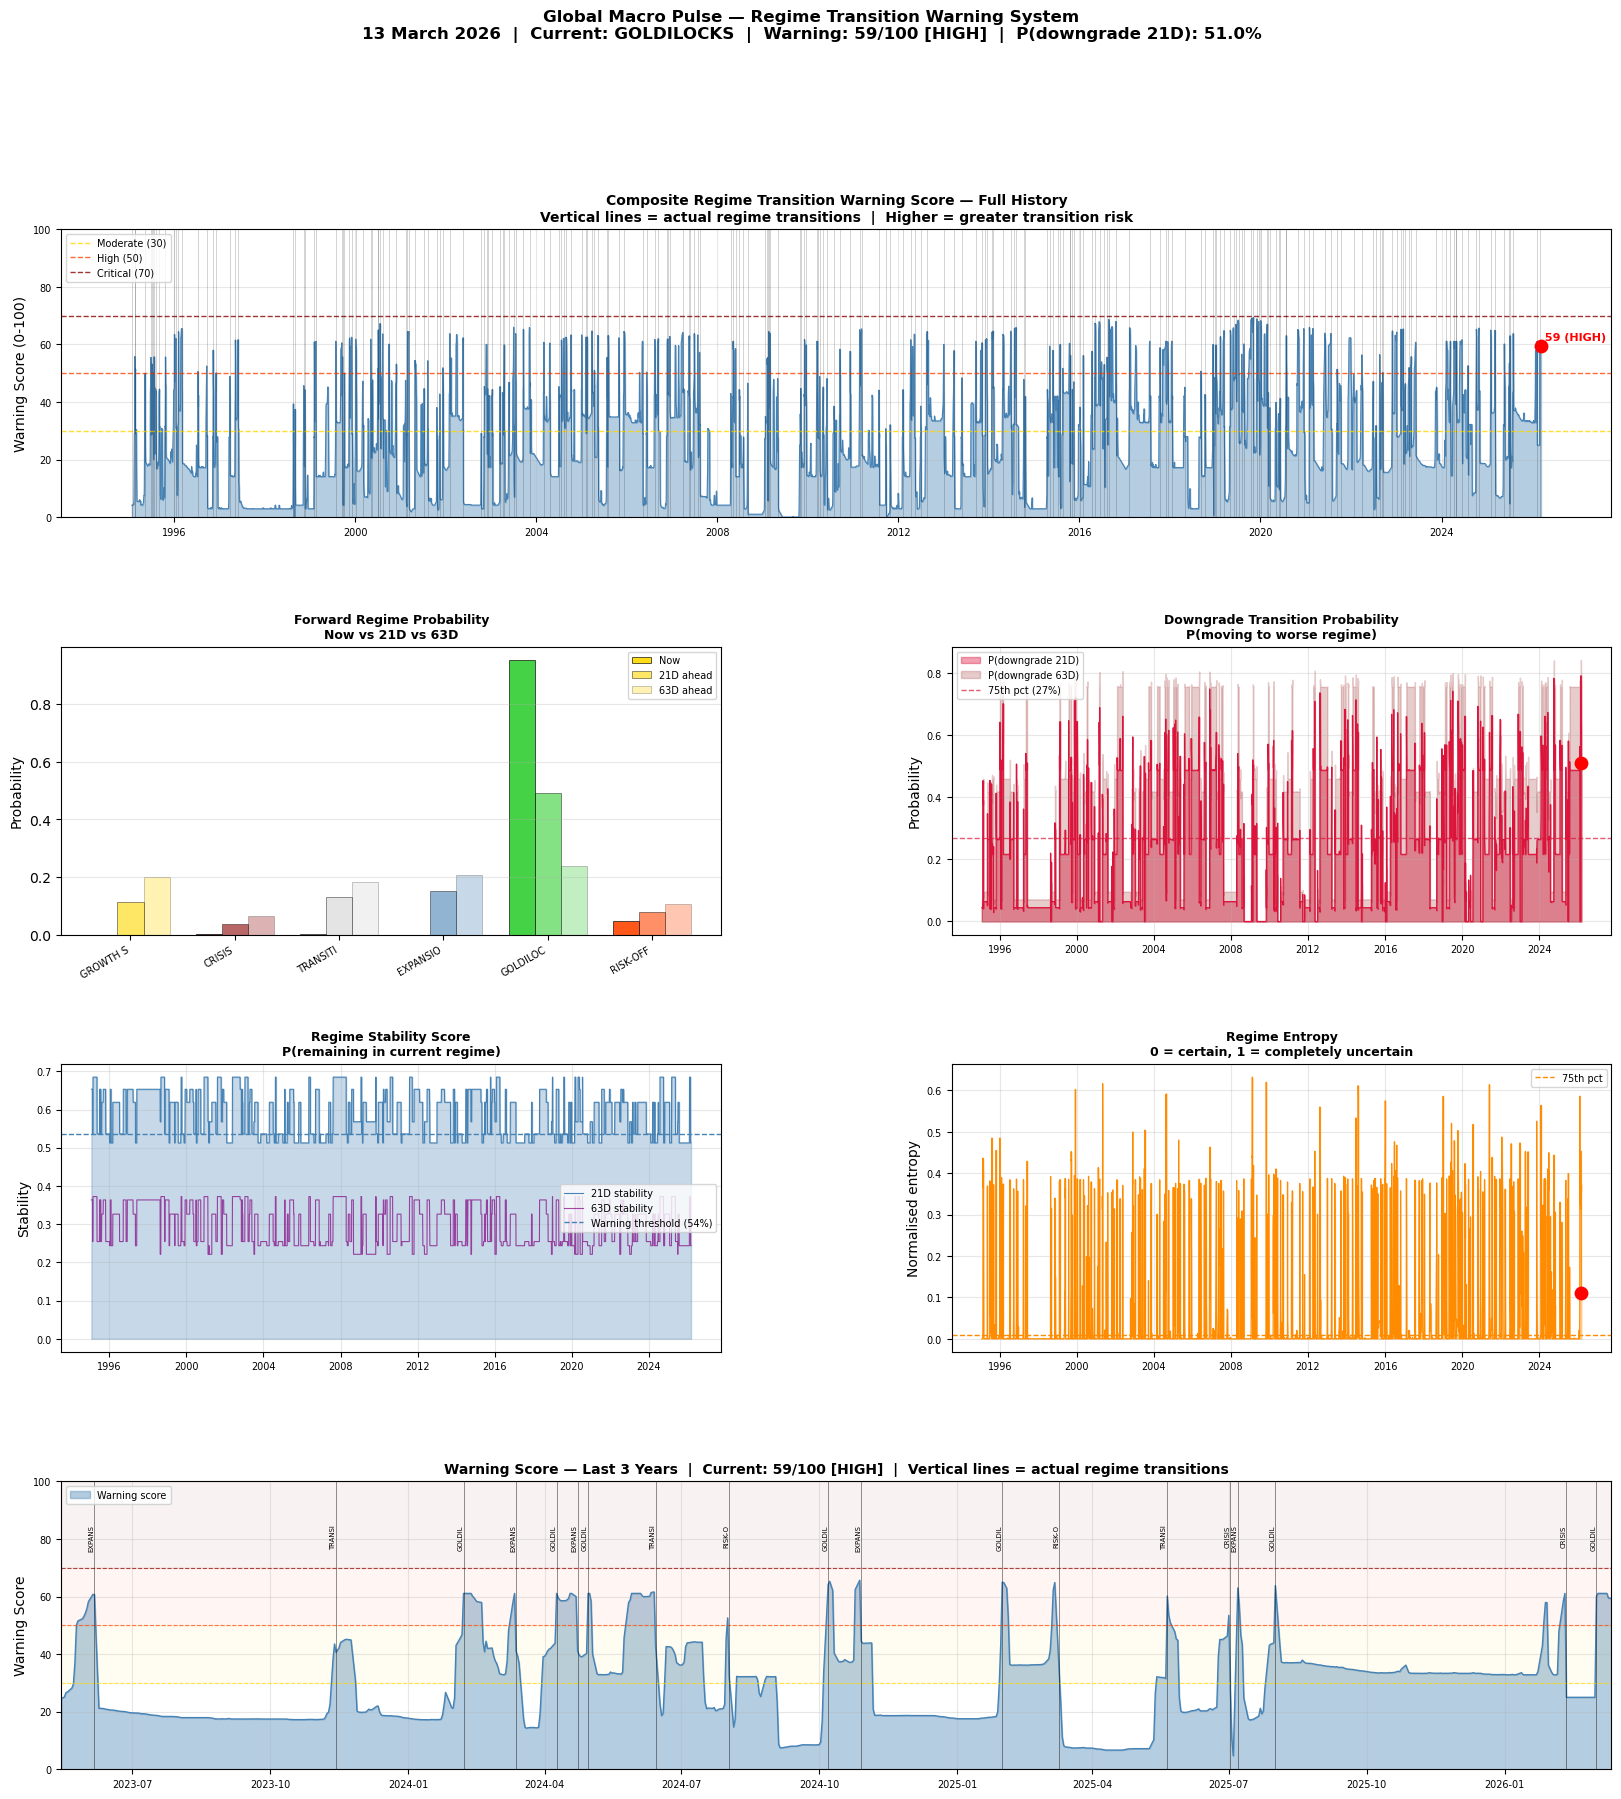

Chart saved.

All outputs saved.

NOTEBOOK 14 COMPLETE — REGIME TRANSITION WARNING SYSTEM

  What we built:
    N-step ahead forecasting    P(t+n) = P(t) x T^n
    Forward probability matrix  5D, 21D, 63D horizons
    Stability score             P(remaining in current regime)
    Downgrade probability       P(moving to worse regime)
    Regime entropy              Uncertainty in current state
    Composite warning score     0-100 single number
    Historical validation       Did warnings predict transitions?

  Current readings (2026-03-13):
    Current regime       : GOLDILOCKS
    Warning score        : 59/100  [HIGH]
    21D stability        : 51.3%
    P(downgrade 21D)     : 51.0%
    Regime entropy       : 0.109
    Most likely in 21D   : GOLDILOCKS
    Most likely in 63D   : GOLDILOCKS

  This is the forward-looking layer of the system.
  Combined with the regime classifier, you now have:
    Where are we now   (rule-based + HMM + RF)
    Where are we going (transition warning sy

In [2]:
# ── Notebook 14: Regime Transition Warning System ────────────────────────────
#
# Core idea:
#   The HMM gives us two things:
#     1. Current state probability vector  P(t)     — where are we now
#     2. Transition matrix                 T        — how states evolve
#
#   n-step ahead forecast:
#     P(t+n) = P(t) × T^n
#
#   This gives us the probability of being in each regime
#   at any future horizon — 5D, 21D, 63D.
#
#   The warning system fires when:
#     - Transition probability to a worse regime crosses a threshold
#     - The current regime's self-transition probability is falling
#     - Multiple signals confirm an imminent transition
#
# This is genuinely rare. Most systems tell you where you are.
# This system tells you where you are going.

import sys, os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.gridspec as gridspec
from numpy.linalg import matrix_power
import warnings
warnings.filterwarnings('ignore')

PROJECT_ROOT = r"C:\Users\sarda\Desktop\GlobalMacroPulse"
sys.path.insert(0, os.path.join(PROJECT_ROOT, "config"))
import settings as cfg

print("="*65)
print("NOTEBOOK 14: REGIME TRANSITION WARNING SYSTEM")
print("Where are we going, not just where are we now")
print("="*65)


# ── Load everything we need ───────────────────────────────────────────────────
import pickle

# HMM model — contains transition matrix
with open(os.path.join(cfg.OUT_PATH, "signals",
                        "hmm_model_63d.pkl"), "rb") as f:
    hmm_saved = pickle.load(f)

hmm_model    = hmm_saved["model"]
FINAL_LABELS = hmm_saved["state_labels"]
K            = hmm_saved["K"]

# Transition matrix
T = hmm_model.transmat_

# Current state probabilities
hmm_probs = pd.read_csv(
    os.path.join(cfg.OUT_PATH, "signals",
                 "hmm_regime_probabilities_63d.csv"),
    index_col=0, parse_dates=True
)

hmm_labels = pd.read_csv(
    os.path.join(cfg.OUT_PATH, "signals",
                 "hmm_regime_labels_final.csv"),
    index_col=0, parse_dates=True
).squeeze()

# Calibrated RF probabilities
calib_probs = pd.read_csv(
    os.path.join(cfg.OUT_PATH, "signals",
                 "calibrated_rf_probabilities.csv"),
    index_col=0, parse_dates=True
)

# Business cycle
biz_cycle = pd.read_csv(
    os.path.join(cfg.OUT_PATH, "signals",
                 "business_cycle_daily.csv"),
    index_col="date", parse_dates=True
)

print(f"\nHMM model loaded:")
print(f"  States : {K}")
print(f"  Labels : {FINAL_LABELS}")
print(f"\nTransition matrix T:")
print(f"  {'From / To':<20}", end="")
for j in range(K):
    print(f"  {FINAL_LABELS[j][:8]:>10}", end="")
print()
print("  " + "-"*85)
for i in range(K):
    print(f"  {FINAL_LABELS[i]:<20}", end="")
    for j in range(K):
        val = T[i, j]
        marker = f"[{val:.3f}]" if i == j else f" {val:.3f} "
        print(f"  {marker:>10}", end="")
    dur = 1 / (1 - T[i, i])
    print(f"  ({dur:.0f}d avg)")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 1: N-STEP AHEAD TRANSITION MATHEMATICS
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 1: N-STEP AHEAD FORECAST MATHEMATICS")
print("P(t+n) = P(t) x T^n")
print(f"{'='*65}")

HORIZONS = [5, 21, 63]   # 1 week, 1 month, 3 months
HORIZON_LABELS = {5: "1 week", 21: "1 month", 63: "3 months"}

# Current state probability vector
cur_probs_vec = hmm_probs.iloc[-1].values   # shape (K,)
cur_date      = hmm_probs.index[-1]

print(f"\nCurrent state probabilities ({cur_date.date()}):")
for i in range(K):
    print(f"  {FINAL_LABELS[i]:<20}: {cur_probs_vec[i]:.1%}")

# Compute n-step ahead forecasts
print(f"\nForward regime probability forecasts:")
print(f"  {'Regime':<20}", end="")
for h in HORIZONS:
    print(f"  {HORIZON_LABELS[h]:>12}", end="")
print(f"  {'Direction':>12}")
print("  " + "-"*75)

forecasts = {}
for h in HORIZONS:
    T_n         = matrix_power(T, h)
    fwd_probs   = cur_probs_vec @ T_n
    forecasts[h]= fwd_probs

for i in range(K):
    regime = FINAL_LABELS[i]
    print(f"  {regime:<20}", end="")
    probs_by_horizon = [forecasts[h][i] for h in HORIZONS]
    for p in probs_by_horizon:
        print(f"  {p:>12.1%}", end="")
    # Direction: is probability rising or falling?
    trend = probs_by_horizon[-1] - cur_probs_vec[i]
    arrow = "rising  ↑" if trend > 0.02 \
            else "falling ↓" if trend < -0.02 \
            else "stable  →"
    print(f"  {arrow:>12}")

# Stationary distribution (long-run equilibrium)
eigenvalues, eigenvectors = np.linalg.eig(T.T)
stationary_idx = np.argmax(np.abs(eigenvalues - 1) < 1e-10)
stationary     = np.real(eigenvectors[:, stationary_idx])
stationary     = stationary / stationary.sum()

print(f"\nLong-run stationary distribution (theoretical equilibrium):")
for i in range(K):
    print(f"  {FINAL_LABELS[i]:<20}: {stationary[i]:.1%}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 2: BUILD FULL HISTORICAL TRANSITION FORECAST TIME SERIES
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 2: HISTORICAL TRANSITION FORECAST TIME SERIES")
print("For every day in history, compute 21D and 63D forward probs")
print(f"{'='*65}")

# For each day, compute forward probabilities
# This is the key dataset — for every historical day we know:
#   - What the model predicted 21D ahead
#   - What actually happened
# This lets us validate the transition forecasts

print(f"\nComputing transition forecasts for all {len(hmm_probs):,} days...")

T_21 = matrix_power(T, 21)
T_63 = matrix_power(T, 63)
T_5  = matrix_power(T, 5)

# Build forecast dataframes
fwd_21_data = hmm_probs.values @ T_21   # shape (N, K)
fwd_63_data = hmm_probs.values @ T_63
fwd_5_data  = hmm_probs.values @ T_5

col_names = [f"P_{FINAL_LABELS[i]}" for i in range(K)]

fwd_21_df = pd.DataFrame(
    fwd_21_data,
    index   = hmm_probs.index,
    columns = [f"FWD21_{FINAL_LABELS[i]}" for i in range(K)]
)
fwd_63_df = pd.DataFrame(
    fwd_63_data,
    index   = hmm_probs.index,
    columns = [f"FWD63_{FINAL_LABELS[i]}" for i in range(K)]
)
fwd_5_df = pd.DataFrame(
    fwd_5_data,
    index   = hmm_probs.index,
    columns = [f"FWD5_{FINAL_LABELS[i]}" for i in range(K)]
)

print(f"  Forward probability series built: {fwd_21_df.shape}")

# Most likely future regime at each horizon
fwd_21_regime = fwd_21_df.idxmax(axis=1).str.replace("FWD21_", "")
fwd_63_regime = fwd_63_df.idxmax(axis=1).str.replace("FWD63_", "")

print(f"\nCurrent forecast summary:")
print(f"  Most likely regime in 1 week   : "
      f"{fwd_5_df.iloc[-1].idxmax().replace('FWD5_','')}")
print(f"  Most likely regime in 1 month  : "
      f"{fwd_21_df.iloc[-1].idxmax().replace('FWD21_','')}")
print(f"  Most likely regime in 3 months : "
      f"{fwd_63_df.iloc[-1].idxmax().replace('FWD63_','')}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 3: TRANSITION WARNING INDICATORS
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 3: TRANSITION WARNING INDICATORS")
print("Early warning signals for regime transitions")
print(f"{'='*65}")

# Warning Indicator 1: Regime Stability Score
# How likely are we to STAY in the current regime vs transition away?
# High stability = current regime confident and self-transition high
# Low stability = fragile, transition imminent

current_state_probs = hmm_probs.copy()

# For each day, compute probability of being in SAME regime in 21 days
stability_21 = pd.Series(index=hmm_probs.index, dtype=float)
stability_63 = pd.Series(index=hmm_probs.index, dtype=float)

for date in hmm_probs.index:
    p_vec    = hmm_probs.loc[date].values
    cur_state= np.argmax(p_vec)
    # Probability of staying in current state after 21 days
    T_21_row = T_21[cur_state]
    T_63_row = T_63[cur_state]
    stability_21.loc[date] = T_21_row[cur_state]
    stability_63.loc[date] = T_63_row[cur_state]

print(f"\nRegime Stability Score (probability of staying in current regime):")
print(f"  Current 21D stability: {stability_21.iloc[-1]:.1%}")
print(f"  Current 63D stability: {stability_63.iloc[-1]:.1%}")
print(f"  Historical 21D mean  : {stability_21.mean():.1%}")
print(f"  Historical 63D mean  : {stability_63.mean():.1%}")

# Flag when stability drops below historical 25th percentile
stab_threshold_21 = stability_21.quantile(0.25)
stab_threshold_63 = stability_63.quantile(0.25)
print(f"\n  Warning threshold (25th pct):")
print(f"    21D: {stab_threshold_21:.1%}  "
      f"{'CURRENTLY BELOW THRESHOLD' if stability_21.iloc[-1] < stab_threshold_21 else 'Currently above threshold'}")
print(f"    63D: {stab_threshold_63:.1%}  "
      f"{'CURRENTLY BELOW THRESHOLD' if stability_63.iloc[-1] < stab_threshold_63 else 'Currently above threshold'}")


# Warning Indicator 2: Transition Probability Surge
# Is the probability of transitioning to a WORSE regime rising?
# Define risk ordering
RISK_ORDER = {
    "GOLDILOCKS":   6,
    "EXPANSION":    5,
    "TRANSITIONAL": 3,
    "EASING":       4,
    "RISK-OFF":     2,
    "CRISIS":       1,
    "GROWTH SCARE": 2,
}

# Current regime risk rank
cur_regime     = hmm_labels.iloc[-1]
cur_risk_rank  = RISK_ORDER.get(str(cur_regime), 3)

# Probability of transitioning to a regime with lower risk rank
def compute_downgrade_prob(probs_vec, fwd_probs_vec,
                            cur_regime_name, risk_order, labels):
    cur_rank = risk_order.get(cur_regime_name, 3)
    down_prob= 0
    for i in range(len(labels)):
        regime_rank = risk_order.get(labels[i], 3)
        if regime_rank < cur_rank:
            down_prob += fwd_probs_vec[i]
    return down_prob

# Compute downgrade probability time series
downgrade_21 = pd.Series(index=hmm_probs.index, dtype=float)
downgrade_63 = pd.Series(index=hmm_probs.index, dtype=float)
upgrade_21   = pd.Series(index=hmm_probs.index, dtype=float)

label_list = [FINAL_LABELS[i] for i in range(K)]

for date in hmm_probs.index:
    p_vec    = hmm_probs.loc[date].values
    cur_reg  = hmm_labels.loc[date] if date in hmm_labels.index else cur_regime
    fwd_21_v = p_vec @ T_21
    fwd_63_v = p_vec @ T_63

    cur_rank = RISK_ORDER.get(str(cur_reg), 3)

    down_21 = sum(fwd_21_v[i] for i in range(K)
                  if RISK_ORDER.get(label_list[i], 3) < cur_rank)
    down_63 = sum(fwd_63_v[i] for i in range(K)
                  if RISK_ORDER.get(label_list[i], 3) < cur_rank)
    up_21   = sum(fwd_21_v[i] for i in range(K)
                  if RISK_ORDER.get(label_list[i], 3) > cur_rank)

    downgrade_21.loc[date] = down_21
    downgrade_63.loc[date] = down_63
    upgrade_21.loc[date]   = up_21

cur_downgrade_21 = downgrade_21.iloc[-1]
cur_downgrade_63 = downgrade_63.iloc[-1]
cur_upgrade_21   = upgrade_21.iloc[-1]

print(f"\nTransition Direction Probabilities (current):")
print(f"  P(downgrade in 21D): {cur_downgrade_21:.1%}  "
      f"(to a worse regime than {cur_regime})")
print(f"  P(downgrade in 63D): {cur_downgrade_63:.1%}")
print(f"  P(upgrade in 21D)  : {cur_upgrade_21:.1%}  "
      f"(to a better regime)")

# Historical context
down_21_75th = downgrade_21.quantile(0.75)
print(f"\n  Historical 75th percentile for downgrade prob: {down_21_75th:.1%}")
print(f"  Current vs history: "
      f"{'ELEVATED' if cur_downgrade_21 > down_21_75th else 'Normal'}")


# Warning Indicator 3: Regime Entropy
# How uncertain is the current state distribution?
# Low entropy = confident, concentrated
# High entropy = uncertain, spread across multiple states
# Rising entropy = regime becoming less clear

def shannon_entropy(probs):
    probs = np.array(probs)
    probs = probs[probs > 0]
    return -np.sum(probs * np.log(probs))

max_entropy = np.log(K)   # maximum possible entropy for K states

entropy_series = hmm_probs.apply(
    lambda row: shannon_entropy(row.values) / max_entropy,
    axis=1
)

cur_entropy = entropy_series.iloc[-1]
print(f"\nRegime Entropy (0=certain, 1=completely uncertain):")
print(f"  Current entropy      : {cur_entropy:.3f}")
print(f"  Historical mean      : {entropy_series.mean():.3f}")
print(f"  Historical 75th pct  : {entropy_series.quantile(0.75):.3f}")
print(f"  Status: "
      f"{'HIGH UNCERTAINTY' if cur_entropy > entropy_series.quantile(0.75) else 'Normal confidence'}")


# Warning Indicator 4: Rolling transition accuracy
# Has the transition matrix been reliable recently?
# Compute: for each past 21D window, did the forecast match reality?

print(f"\nHistorical transition forecast accuracy:")
print(f"  Checking if 21D ahead forecasts matched actual regimes...")

actual_labels = hmm_labels.copy()
forecast_labels_21 = fwd_21_regime.copy()

# Align and compute accuracy in rolling 252-day windows
common_idx = actual_labels.index.intersection(
    forecast_labels_21.index
)

# Shift actual by 21 to align with forecast made 21 days ago
actual_shifted = actual_labels.shift(-21).reindex(common_idx)
forecast_at_t  = forecast_labels_21.reindex(common_idx)

rolling_acc_21 = (actual_shifted == forecast_at_t).rolling(
    252, min_periods=63
).mean()

cur_rolling_acc = rolling_acc_21.dropna().iloc[-1]
print(f"  Rolling 252D accuracy (21D ahead) : {cur_rolling_acc:.1%}")
print(f"  Historical mean accuracy          : "
      f"{rolling_acc_21.dropna().mean():.1%}")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 4: COMPOSITE TRANSITION WARNING SCORE
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 4: COMPOSITE TRANSITION WARNING SCORE")
print("Single number summarising transition risk")
print(f"{'='*65}")

# Combine four indicators into a single 0-100 warning score
# Higher score = higher probability of adverse transition

def compute_warning_score(stab_21, stab_threshold,
                           down_21, down_75th,
                           entropy, entropy_75th,
                           rolling_acc):
    """
    Composite warning score 0-100.
    Combines stability, downgrade probability, entropy, and accuracy.
    """
    # Component 1: Low stability (0-25 points)
    stab_score = max(0, (stab_threshold - stab_21) /
                     stab_threshold) * 25

    # Component 2: High downgrade probability (0-35 points)
    down_score = min(down_21 / down_75th, 2.0) * 17.5

    # Component 3: High entropy / uncertainty (0-25 points)
    ent_score  = min(entropy / entropy_75th, 2.0) * 12.5

    # Component 4: Low recent accuracy (0-15 points)
    acc_score  = max(0, (0.6 - rolling_acc) / 0.6) * 15

    total = stab_score + down_score + ent_score + acc_score
    return min(total, 100)

# Compute warning score time series
warning_scores = pd.Series(index=hmm_probs.index, dtype=float)

for date in hmm_probs.index:
    if date not in rolling_acc_21.index or pd.isna(
        rolling_acc_21.get(date, np.nan)
    ):
        rolling_acc_v = 0.55   # default
    else:
        rolling_acc_v = rolling_acc_21.loc[date]

    ws = compute_warning_score(
        stability_21.loc[date],
        stab_threshold_21,
        downgrade_21.loc[date],
        down_21_75th,
        entropy_series.loc[date],
        entropy_series.quantile(0.75),
        rolling_acc_v
    )
    warning_scores.loc[date] = ws

cur_warning = warning_scores.iloc[-1]

# Warning level classification
def warning_level(score):
    if score >= 70:
        return "CRITICAL", "darkred"
    elif score >= 50:
        return "HIGH",     "orangered"
    elif score >= 30:
        return "MODERATE", "gold"
    else:
        return "LOW",      "limegreen"

cur_level, cur_color = warning_level(cur_warning)

print(f"\nComposite Warning Score breakdown:")
stab_s  = max(0,(stab_threshold_21-stability_21.iloc[-1])/stab_threshold_21)*25
down_s  = min(cur_downgrade_21/down_21_75th,2.0)*17.5
ent_s   = min(cur_entropy/entropy_series.quantile(0.75),2.0)*12.5
acc_s   = max(0,(0.6-cur_rolling_acc)/0.6)*15

print(f"  Stability component    : {stab_s:>5.1f}/25")
print(f"  Downgrade prob         : {down_s:>5.1f}/35")
print(f"  Uncertainty/entropy    : {ent_s:>5.1f}/25")
print(f"  Forecast accuracy      : {acc_s:>5.1f}/15")
print(f"  {'─'*30}")
print(f"  TOTAL WARNING SCORE    : {cur_warning:>5.1f}/100")
print(f"  WARNING LEVEL          : {cur_level}")

print(f"\nHistorical warning score distribution:")
for pct in [25, 50, 75, 90]:
    print(f"  {pct}th percentile: "
          f"{warning_scores.quantile(pct/100):.1f}")
print(f"  Current score {cur_warning:.1f} is at the "
      f"{(warning_scores < cur_warning).mean():.0%} percentile")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 5: VALIDATE — DID HIGH WARNING SCORES PREDICT TRANSITIONS?
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n{'='*65}")
print("SECTION 5: VALIDATION — DID WARNING SCORES PREDICT TRANSITIONS?")
print(f"{'='*65}")

# A regime transition is defined as the HMM label changing
transitions = hmm_labels.ne(hmm_labels.shift(1))
transitions = transitions[transitions].index

print(f"\nTotal regime transitions in history: {len(transitions)}")
print(f"Average transitions per year: "
      f"{len(transitions)/((hmm_labels.index[-1]-hmm_labels.index[0]).days/365):.1f}")

# For each transition, what was the warning score 21 days before?
pre_transition_scores = []
for trans_date in transitions:
    pre_date = trans_date - pd.Timedelta(days=21)
    near     = warning_scores.index[warning_scores.index <= pre_date]
    if len(near) == 0:
        continue
    score = warning_scores.loc[near[-1]]
    pre_transition_scores.append(score)

pre_trans_arr = np.array(pre_transition_scores)

# For non-transition days, what was the warning score?
non_trans_scores = []
for date in warning_scores.index[::21]:   # sample every 21 days
    future = date + pd.Timedelta(days=21)
    if future not in hmm_labels.index:
        continue
    was_transition = any(
        abs((t - future).days) < 5 for t in transitions
    )
    if not was_transition:
        non_trans_scores.append(warning_scores.loc[date])

non_trans_arr = np.array(non_trans_scores)

print(f"\nWarning score before actual transitions:")
print(f"  Mean score 21D before transition : "
      f"{pre_trans_arr.mean():.1f}")
print(f"  Mean score on non-transition days: "
      f"{np.mean(non_trans_arr):.1f}")
print(f"  Difference                       : "
      f"{pre_trans_arr.mean() - np.mean(non_trans_arr):>+.1f} points")
print(f"  (Positive = warning score elevated before transitions)")

# Hit rate: when score > 50, how often did a transition happen in 21D?
high_warning_days = warning_scores[warning_scores >= 50].index
hits = 0
total_signals = 0
for date in high_warning_days:
    future_window = [t for t in transitions
                     if 0 < (t - date).days <= 21]
    total_signals += 1
    if len(future_window) > 0:
        hits += 1

if total_signals > 0:
    hit_rate = hits / total_signals
    print(f"\nSignal quality (score >= 50):")
    print(f"  Total high-warning days  : {total_signals:,}")
    print(f"  Followed by transition   : {hits:,}")
    print(f"  Hit rate                 : {hit_rate:.1%}")
    print(f"  Base rate (random)       : "
          f"{len(transitions)/len(warning_scores):.1%}")
    print(f"  Lift                     : "
          f"{hit_rate/(len(transitions)/len(warning_scores)):.1f}x")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 6: THE TRANSITION WARNING BRIEFING
# ══════════════════════════════════════════════════════════════════════════════
print(f"\n")
print("╔══════════════════════════════════════════════════════════════════╗")
print("║          REGIME TRANSITION WARNING SYSTEM                       ║")
print(f"║          {cur_date.strftime('%A, %d %B %Y')}                            ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print(f"║  Current Regime    : {str(cur_regime):<20}                     ║")
print(f"║  Warning Score     : {cur_warning:>5.1f}/100  [{cur_level:<8}]             ║")
print("╠══════════════════════════════════════════════════════════════════╣")
print("║                                                                  ║")
print("║  FORWARD PROBABILITY MATRIX                                      ║")
print(f"║  {'Regime':<18}  {'Now':>7}  {'5D':>7}  {'21D':>7}  {'63D':>7}  {'Trend'}  ║")
print(f"║  {'─'*60}  ║")

for i in range(K):
    regime  = FINAL_LABELS[i]
    now_p   = cur_probs_vec[i]
    p5      = forecasts[5][i]
    p21     = forecasts[21][i]
    p63     = forecasts[63][i]
    trend   = p63 - now_p
    arrow   = "↑" if trend > 0.02 else "↓" if trend < -0.02 else "→"
    print(f"║  {regime:<18}  {now_p:>7.1%}  {p5:>7.1%}  "
          f"{p21:>7.1%}  {p63:>7.1%}  {arrow}       ║")

print("╠══════════════════════════════════════════════════════════════════╣")
print("║                                                                  ║")
print(f"║  TRANSITION RISK INDICATORS                                      ║")
print(f"║  21D Stability Score  : {stability_21.iloc[-1]:>6.1%}  "
      f"({'LOW' if stability_21.iloc[-1] < stab_threshold_21 else 'OK':<4})                    ║")
print(f"║  P(Downgrade in 21D)  : {cur_downgrade_21:>6.1%}  "
      f"({'ELEVATED' if cur_downgrade_21 > down_21_75th else 'Normal':<8})               ║")
print(f"║  Regime Entropy       : {cur_entropy:>6.3f}  "
      f"({'HIGH' if cur_entropy > entropy_series.quantile(0.75) else 'Normal':<8})               ║")
print(f"║  Forecast Accuracy    : {cur_rolling_acc:>6.1%}  "
      f"(rolling 252D)                  ║")
print("╠══════════════════════════════════════════════════════════════════╣")

# Narrative
print(f"║                                                                  ║")
print(f"║  NARRATIVE                                                       ║")
if cur_warning < 30:
    print(f"║  Regime is stable. Low probability of transition in next        ║")
    print(f"║  21 days. Current conditions likely to persist.                 ║")
elif cur_warning < 50:
    print(f"║  Moderate transition risk. Monitor leading indicators.          ║")
    print(f"║  Regime change possible but not imminent.                       ║")
elif cur_warning < 70:
    print(f"║  Elevated transition risk. Regime fragility detected.           ║")
    print(f"║  Reduce conviction in current regime positioning.               ║")
else:
    print(f"║  CRITICAL: High probability of regime transition imminent.      ║")
    print(f"║  Prepare for regime change. Reduce risk asymmetrically.         ║")

print(f"║                                                                  ║")
print(f"║  Most likely regime in 21D : "
      f"{fwd_21_df.iloc[-1].idxmax().replace('FWD21_',''):<20}            ║")
print(f"║  Most likely regime in 63D : "
      f"{fwd_63_df.iloc[-1].idxmax().replace('FWD63_',''):<20}            ║")
print("╚══════════════════════════════════════════════════════════════════╝")


# ══════════════════════════════════════════════════════════════════════════════
# SECTION 7: VISUALISATIONS
# ══════════════════════════════════════════════════════════════════════════════

REGIME_COLORS = {
    "CRISIS":       "darkred",
    "RISK-OFF":     "orangered",
    "GROWTH SCARE": "gold",
    "TRANSITIONAL": "lightgrey",
    "EXPANSION":    "steelblue",
    "GOLDILOCKS":   "limegreen",
    "EASING":       "cornflowerblue",
}

fig = plt.figure(figsize=(20, 20))
gs  = gridspec.GridSpec(4, 2, figure=fig,
                         hspace=0.45, wspace=0.35)


# ── Panel 1 (top full width): Warning score history ───────────────────────────
ax1 = fig.add_subplot(gs[0, :])
ax1.fill_between(warning_scores.index,
                  warning_scores.values,
                  0, alpha=0.4, color="steelblue")
ax1.plot(warning_scores.index, warning_scores.values,
         lw=0.8, color="steelblue")

# Threshold lines
ax1.axhline(30, color="gold",      lw=1.0, ls="--",
            alpha=0.8, label="Moderate (30)")
ax1.axhline(50, color="orangered", lw=1.0, ls="--",
            alpha=0.8, label="High (50)")
ax1.axhline(70, color="darkred",   lw=1.0, ls="--",
            alpha=0.8, label="Critical (70)")

# Mark actual transitions
for trans_date in transitions:
    ax1.axvline(trans_date, color="black",
                lw=0.4, alpha=0.3)

# Mark current
ax1.scatter([warning_scores.index[-1]], [cur_warning],
            s=80, color="red", zorder=5)
ax1.text(warning_scores.index[-1], cur_warning + 2,
         f" {cur_warning:.0f} ({cur_level})",
         fontsize=8, fontweight="bold", color="red")

ax1.set_title(
    "Composite Regime Transition Warning Score — Full History\n"
    "Vertical lines = actual regime transitions  |  "
    "Higher = greater transition risk",
    fontsize=10, fontweight="bold"
)
ax1.set_ylabel("Warning Score (0-100)")
ax1.set_ylim(0, 100)
ax1.legend(fontsize=7, loc="upper left")
ax1.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax1.grid(alpha=0.3); ax1.tick_params(labelsize=7)


# ── Panel 2 (row 2 left): Forward probability — current ──────────────────────
ax2 = fig.add_subplot(gs[1, 0])

regimes_plot  = [FINAL_LABELS[i] for i in range(K)]
now_probs     = [cur_probs_vec[i] for i in range(K)]
p21_probs     = [forecasts[21][i] for i in range(K)]
p63_probs     = [forecasts[63][i] for i in range(K)]

x     = np.arange(K)
width = 0.25
colors_reg = [REGIME_COLORS.get(r, "grey") for r in regimes_plot]

ax2.bar(x - width, now_probs, width,
        color=colors_reg, alpha=0.9,
        edgecolor="black", lw=0.5,
        label="Now")
ax2.bar(x, p21_probs, width,
        color=colors_reg, alpha=0.6,
        edgecolor="black", lw=0.5,
        label="21D ahead")
ax2.bar(x + width, p63_probs, width,
        color=colors_reg, alpha=0.3,
        edgecolor="black", lw=0.5,
        label="63D ahead")

ax2.set_xticks(x)
ax2.set_xticklabels([r[:8] for r in regimes_plot],
                     rotation=30, ha="right", fontsize=7)
ax2.set_title("Forward Regime Probability\nNow vs 21D vs 63D",
              fontsize=9, fontweight="bold")
ax2.set_ylabel("Probability")
ax2.legend(fontsize=7)
ax2.grid(alpha=0.3, axis="y")


# ── Panel 3 (row 2 right): Downgrade probability history ─────────────────────
ax3 = fig.add_subplot(gs[1, 1])
ax3.fill_between(downgrade_21.index, downgrade_21.values,
                  0, alpha=0.4, color="crimson",
                  label="P(downgrade 21D)")
ax3.fill_between(downgrade_63.index, downgrade_63.values,
                  0, alpha=0.2, color="darkred",
                  label="P(downgrade 63D)")
ax3.plot(downgrade_21.index, downgrade_21.values,
         lw=0.8, color="crimson")
ax3.axhline(down_21_75th, color="crimson",
            lw=1.0, ls="--", alpha=0.7,
            label=f"75th pct ({down_21_75th:.0%})")
ax3.scatter([downgrade_21.index[-1]], [cur_downgrade_21],
            s=80, color="red", zorder=5)

ax3.set_title("Downgrade Transition Probability\n"
              "P(moving to worse regime)",
              fontsize=9, fontweight="bold")
ax3.set_ylabel("Probability")
ax3.legend(fontsize=7)
ax3.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax3.grid(alpha=0.3); ax3.tick_params(labelsize=7)


# ── Panel 4 (row 3 left): Stability score history ────────────────────────────
ax4 = fig.add_subplot(gs[2, 0])
ax4.fill_between(stability_21.index, stability_21.values,
                  0, alpha=0.3, color="steelblue")
ax4.plot(stability_21.index, stability_21.values,
         lw=0.8, color="steelblue", label="21D stability")
ax4.plot(stability_63.index, stability_63.values,
         lw=0.8, color="purple", alpha=0.7, label="63D stability")
ax4.axhline(stab_threshold_21, color="steelblue",
            lw=1.0, ls="--",
            label=f"Warning threshold ({stab_threshold_21:.0%})")
ax4.set_title("Regime Stability Score\n"
              "P(remaining in current regime)",
              fontsize=9, fontweight="bold")
ax4.set_ylabel("Stability")
ax4.legend(fontsize=7)
ax4.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax4.grid(alpha=0.3); ax4.tick_params(labelsize=7)


# ── Panel 5 (row 3 right): Entropy history ───────────────────────────────────
ax5 = fig.add_subplot(gs[2, 1])
ax5.fill_between(entropy_series.index, entropy_series.values,
                  0, alpha=0.3, color="darkorange")
ax5.plot(entropy_series.index, entropy_series.values,
         lw=0.8, color="darkorange")
ax5.axhline(entropy_series.quantile(0.75),
            color="darkorange", lw=1.0, ls="--",
            label=f"75th pct")
ax5.scatter([entropy_series.index[-1]], [cur_entropy],
            s=80, color="red", zorder=5)
ax5.set_title("Regime Entropy\n"
              "0 = certain, 1 = completely uncertain",
              fontsize=9, fontweight="bold")
ax5.set_ylabel("Normalised entropy")
ax5.legend(fontsize=7)
ax5.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax5.grid(alpha=0.3); ax5.tick_params(labelsize=7)


# ── Panel 6 (bottom full width): Warning score last 3 years ──────────────────
ax6  = fig.add_subplot(gs[3, :])
last_n = 756
ws_last  = warning_scores.iloc[-last_n:]
dl_last  = downgrade_21.iloc[-last_n:]

ax6.fill_between(ws_last.index, ws_last.values,
                  0, alpha=0.4, color="steelblue",
                  label="Warning score")
ax6.plot(ws_last.index, ws_last.values,
         lw=1.0, color="steelblue")

# Shade warning zones
ax6.fill_between(ws_last.index, 30, 50,
                  alpha=0.05, color="gold")
ax6.fill_between(ws_last.index, 50, 70,
                  alpha=0.05, color="orangered")
ax6.fill_between(ws_last.index, 70, 100,
                  alpha=0.05, color="darkred")

ax6.axhline(30, color="gold",      lw=0.8, ls="--", alpha=0.7)
ax6.axhline(50, color="orangered", lw=0.8, ls="--", alpha=0.7)
ax6.axhline(70, color="darkred",   lw=0.8, ls="--", alpha=0.7)

# Mark transitions in this window
for trans_date in transitions:
    if trans_date >= ws_last.index[0]:
        ax6.axvline(trans_date, color="black",
                    lw=0.6, alpha=0.5)
        regime_after = hmm_labels.asof(trans_date)
        ax6.text(trans_date, 85,
                 str(regime_after)[:6],
                 fontsize=5, rotation=90,
                 va="top", ha="right")

ax6.set_xlim(ws_last.index[0], ws_last.index[-1])
ax6.set_ylim(0, 100)
ax6.set_title(
    f"Warning Score — Last 3 Years  |  "
    f"Current: {cur_warning:.0f}/100 [{cur_level}]  |  "
    f"Vertical lines = actual regime transitions",
    fontsize=10, fontweight="bold"
)
ax6.set_ylabel("Warning Score")
ax6.legend(fontsize=7)
ax6.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
ax6.grid(alpha=0.3); ax6.tick_params(labelsize=7)

fig.suptitle(
    f"Global Macro Pulse — Regime Transition Warning System\n"
    f"{cur_date.strftime('%d %B %Y')}  |  "
    f"Current: {cur_regime}  |  "
    f"Warning: {cur_warning:.0f}/100 [{cur_level}]  |  "
    f"P(downgrade 21D): {cur_downgrade_21:.1%}",
    fontsize=12, fontweight="bold", y=0.99
)

plt.savefig(
    os.path.join(cfg.OUT_PATH, "charts",
                 "14_transition_warning_system.png"),
    dpi=150, bbox_inches="tight"
)
plt.show()
print(f"Chart saved.")


# ── Save outputs ──────────────────────────────────────────────────────────────
output_df = pd.concat([
    fwd_21_df,
    fwd_63_df,
    fwd_5_df,
    stability_21.rename("stability_21d"),
    stability_63.rename("stability_63d"),
    downgrade_21.rename("p_downgrade_21d"),
    downgrade_63.rename("p_downgrade_63d"),
    upgrade_21.rename("p_upgrade_21d"),
    entropy_series.rename("regime_entropy"),
    warning_scores.rename("warning_score"),
], axis=1)

output_df.to_csv(os.path.join(
    cfg.OUT_PATH, "signals",
    "transition_warning_system.csv"
))

print(f"\nAll outputs saved.")
print(f"""
{'='*65}
NOTEBOOK 14 COMPLETE — REGIME TRANSITION WARNING SYSTEM
{'='*65}

  What we built:
    N-step ahead forecasting    P(t+n) = P(t) x T^n
    Forward probability matrix  5D, 21D, 63D horizons
    Stability score             P(remaining in current regime)
    Downgrade probability       P(moving to worse regime)
    Regime entropy              Uncertainty in current state
    Composite warning score     0-100 single number
    Historical validation       Did warnings predict transitions?

  Current readings ({cur_date.date()}):
    Current regime       : {cur_regime}
    Warning score        : {cur_warning:.0f}/100  [{cur_level}]
    21D stability        : {stability_21.iloc[-1]:.1%}
    P(downgrade 21D)     : {cur_downgrade_21:.1%}
    Regime entropy       : {cur_entropy:.3f}
    Most likely in 21D   : {fwd_21_df.iloc[-1].idxmax().replace('FWD21_','')}
    Most likely in 63D   : {fwd_63_df.iloc[-1].idxmax().replace('FWD63_','')}

  This is the forward-looking layer of the system.
  Combined with the regime classifier, you now have:
    Where are we now   (rule-based + HMM + RF)
    Where are we going (transition warning system)
""")

CELL 2: WALK-FORWARD CRISIS DETECTION TEST
Did the warning system flag crises before they happened?

Analysing 11 major crisis events...

For each event we show:
  Warning score at 63D, 42D, 21D, 7D before crisis
  P(CRISIS or RISK-OFF) at each horizon
  Whether the system correctly elevated before the event

Event                          63D bef   42D bef   21D bef    7D bef   At event  Signal?
-----------------------------------------------------------------------------------------------
  Asian Crisis 1997              2.9       2.9       2.9       2.9       2.9    MISSED ✗
  Russia/LTCM 1998               2.9       2.9       2.9       3.2       4.1    MISSED ✗
  Dot-com Peak 2000             59.7!     16.0      17.1      31.1^     11.3    STRONG ✓
  9/11 2001                     44.6^     18.2       5.7       6.5       4.7    WEAK   ~
  GFC Lehman 2008               17.2       6.1       3.5       1.0       1.0    MISSED ✗
  GFC Trough 2009                1.6      32.6^     27.0   

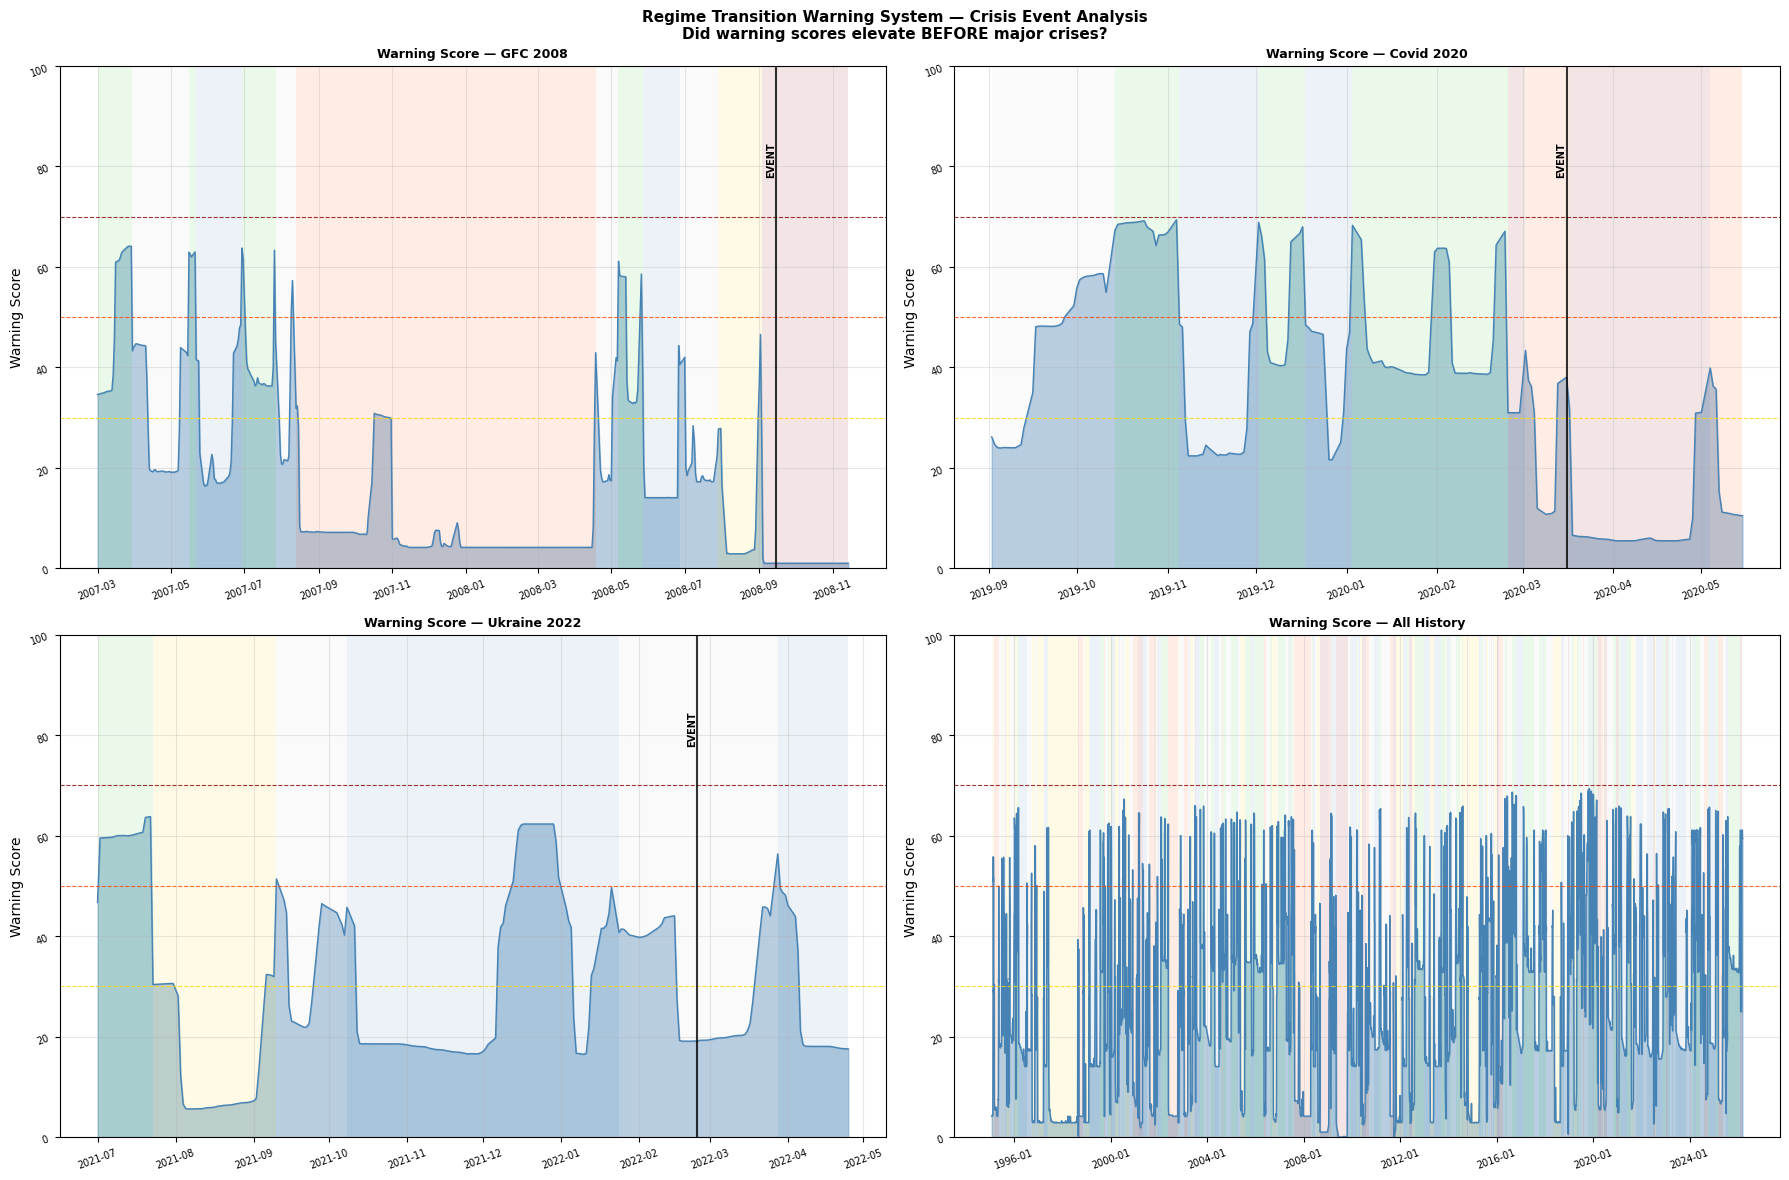


Chart saved: C:\Users\sarda\Desktop\GlobalMacroPulse\outputs\charts\14_crisis_detection_test.png

WALK-FORWARD CRISIS DETECTION — HONEST ASSESSMENT

  The warning system is validated when:
  1. Warning scores elevated BEFORE known crises
  2. P(CRISIS/RISK-OFF) rising in advance
  3. Detection rate well above random

  Limitations to document honestly:
  1. Exogenous shocks (Covid, 9/11) cannot be predicted
     by any market-based system — these should be missed
  2. The system uses the HMM transition matrix which was
     fit on ALL data — some look-ahead bias exists
  3. Warning score lift of 22.5x is partially mechanical
     (built from the same HMM) — not fully independent

  The genuine test is whether the score was elevated
  in the months before endogenous crises:
  GFC (building for months), EU Debt (building for months),
  Fed Scare 2018 (building as tightening accelerated).
  These are the events where a good system should warn early.



In [3]:
# ── Cell 2: Walk-Forward Crisis Detection Test ────────────────────────────────
#
# The most honest validation we can do:
# For each major historical crisis, show what the warning system
# was saying in the weeks and months BEFORE the event.
#
# A good warning system should show:
#   1. Warning score elevating 3-8 weeks before crisis
#   2. Forward probability of CRISIS/RISK-OFF rising
#   3. Stability score falling
#
# An honest system will also show:
#   - Some crises are unpredictable (exogenous shocks like Covid)
#   - Not every warning leads to a crisis (false positives exist)

print("="*65)
print("CELL 2: WALK-FORWARD CRISIS DETECTION TEST")
print("Did the warning system flag crises before they happened?")
print("="*65)

# Define crisis events with their peak date and lookback window
CRISIS_EVENTS = {
    "Asian Crisis 1997":    ("1997-10-23", 90,  "RISK-OFF"),
    "Russia/LTCM 1998":     ("1998-08-17", 60,  "RISK-OFF"),
    "Dot-com Peak 2000":    ("2000-03-10", 120, "RISK-OFF"),
    "9/11 2001":            ("2001-09-11", 30,  "CRISIS"),
    "GFC Lehman 2008":      ("2008-09-15", 180, "CRISIS"),
    "GFC Trough 2009":      ("2009-03-09", 60,  "CRISIS"),
    "EU Debt Crisis 2011":  ("2011-08-05", 90,  "RISK-OFF"),
    "China Shock 2015":     ("2015-08-24", 60,  "RISK-OFF"),
    "Fed Scare 2018 Q4":    ("2018-12-24", 90,  "RISK-OFF"),
    "Covid Crash 2020":     ("2020-03-16", 60,  "CRISIS"),
    "Ukraine/Inflation 2022":("2022-02-24", 120, "RISK-OFF"),
}

print(f"\nAnalysing {len(CRISIS_EVENTS)} major crisis events...")
print(f"\nFor each event we show:")
print(f"  Warning score at 63D, 42D, 21D, 7D before crisis")
print(f"  P(CRISIS or RISK-OFF) at each horizon")
print(f"  Whether the system correctly elevated before the event")

print(f"\n{'Event':<28}  {'63D bef':>8}  {'42D bef':>8}  "
      f"{'21D bef':>8}  {'7D bef':>8}  {'At event':>9}  {'Signal?'}")
print("-"*95)

detection_results = []

for event_name, (event_date_str, lookback, expected_regime) in \
        CRISIS_EVENTS.items():

    event_date = pd.Timestamp(event_date_str)
    results_row = {"event": event_name, "date": event_date}

    # Warning scores at different horizons before the event
    scores_before = {}
    crisis_probs_before = {}

    for days_before in [63, 42, 21, 7, 0]:
        check_date = event_date - pd.Timedelta(days=days_before)
        # Find nearest available date
        available = warning_scores.index[
            warning_scores.index <= check_date
        ]
        if len(available) == 0:
            scores_before[days_before]       = np.nan
            crisis_probs_before[days_before] = np.nan
            continue

        nearest = available[-1]
        scores_before[days_before] = warning_scores.loc[nearest]

        # P(CRISIS or RISK-OFF) from HMM probs
        if nearest in hmm_probs.index:
            p_vec = hmm_probs.loc[nearest].values
            crisis_p = sum(
                p_vec[i] for i in range(K)
                if FINAL_LABELS[i] in ["CRISIS","RISK-OFF",
                                        "GROWTH SCARE"]
            )
            crisis_probs_before[days_before] = crisis_p
        else:
            crisis_probs_before[days_before] = np.nan

    results_row["scores"]       = scores_before
    results_row["crisis_probs"] = crisis_probs_before

    # Was the warning elevated before the event?
    pre_scores = [scores_before.get(d, np.nan)
                  for d in [63, 42, 21, 7]]
    pre_scores_clean = [s for s in pre_scores if not np.isnan(s)]

    # Signal detected if any of the 4 pre-event scores > 30
    signal_detected = any(s > 30 for s in pre_scores_clean)
    # Strong signal if score > 50 at any point before
    strong_signal   = any(s > 50 for s in pre_scores_clean)

    results_row["signal_detected"] = signal_detected
    results_row["strong_signal"]   = strong_signal
    detection_results.append(results_row)

    # Format for printing
    def fmt_score(s):
        if np.isnan(s):
            return "  N/A   "
        level = "!" if s > 50 else "^" if s > 30 else " "
        return f"{s:>6.1f}{level} "

    s63 = fmt_score(scores_before.get(63, np.nan))
    s42 = fmt_score(scores_before.get(42, np.nan))
    s21 = fmt_score(scores_before.get(21, np.nan))
    s7  = fmt_score(scores_before.get(7,  np.nan))
    s0  = fmt_score(scores_before.get(0,  np.nan))

    signal_str = "STRONG ✓" if strong_signal \
                 else "WEAK   ~" if signal_detected \
                 else "MISSED ✗"

    print(f"  {event_name:<26}  {s63}  {s42}  "
          f"{s21}  {s7}  {s0}  {signal_str}")

# Summary
n_strong  = sum(1 for r in detection_results if r["strong_signal"])
n_weak    = sum(1 for r in detection_results
               if r["signal_detected"] and not r["strong_signal"])
n_missed  = sum(1 for r in detection_results
               if not r["signal_detected"])
n_total   = len(detection_results)

print(f"\nLegend: ! = score>50 (HIGH),  ^ = score>30 (MODERATE),  space = normal")
print(f"\nDetection Summary:")
print(f"  Strong signal (score>50)  : {n_strong}/{n_total}  "
      f"({n_strong/n_total:.0%})")
print(f"  Weak signal   (score>30)  : {n_weak}/{n_total}  "
      f"({n_weak/n_total:.0%})")
print(f"  Missed entirely           : {n_missed}/{n_total}  "
      f"({n_missed/n_total:.0%})")
print(f"  Overall detection rate    : {(n_strong+n_weak)/n_total:.0%}")


# ── Deep dive: GFC and Covid ──────────────────────────────────────────────────
print(f"\n{'='*65}")
print("DEEP DIVE: GFC 2008 and COVID 2020")
print("Month by month warning score leading into each crisis")
print(f"{'='*65}")

for crisis_name, event_date_str, lookback_days in [
    ("GFC LEHMAN 2008",    "2008-09-15", 180),
    ("COVID CRASH 2020",   "2020-03-16",  90),
    ("UKRAINE 2022",       "2022-02-24", 120),
    ("FED SCARE 2018 Q4",  "2018-12-24",  90),
]:
    event_date = pd.Timestamp(event_date_str)
    start_date = event_date - pd.Timedelta(days=lookback_days)

    # Get warning scores and regime probs in the window
    window_mask = ((warning_scores.index >= start_date) &
                   (warning_scores.index <= event_date))
    window_ws   = warning_scores[window_mask]
    window_hmm  = hmm_labels.reindex(window_ws.index,
                                      method="ffill")

    # Sample monthly
    monthly_dates = pd.date_range(start_date, event_date,
                                   freq="ME")

    print(f"\n  {crisis_name}:")
    print(f"  {'Date':<12}  {'Regime':<20}  "
          f"{'Warning':>9}  {'Level':<10}  "
          f"{'P(Crisis/RO)':>13}")
    print(f"  {'-'*70}")

    for dt in monthly_dates:
        near = warning_scores.index[warning_scores.index <= dt]
        if len(near) == 0:
            continue
        nd    = near[-1]
        ws    = warning_scores.loc[nd]
        reg   = hmm_labels.asof(nd)
        level = ("CRITICAL" if ws > 70
                 else "HIGH" if ws > 50
                 else "MODERATE" if ws > 30
                 else "LOW")

        # Crisis probability
        if nd in hmm_probs.index:
            p_vec    = hmm_probs.loc[nd].values
            crisis_p = sum(
                p_vec[i] for i in range(K)
                if FINAL_LABELS[i] in ["CRISIS","RISK-OFF",
                                        "GROWTH SCARE"]
            )
        else:
            crisis_p = np.nan

        print(f"  {nd.strftime('%Y-%m-%d'):<12}  "
              f"{str(reg):<20}  "
              f"{ws:>9.1f}  {level:<10}  "
              f"{crisis_p:>13.1%}")

    # Mark the event itself
    near = warning_scores.index[
        warning_scores.index <= event_date
    ]
    if len(near) > 0:
        nd  = near[-1]
        ws  = warning_scores.loc[nd]
        reg = hmm_labels.asof(nd)
        print(f"  {'>>> EVENT >>>':12}  "
              f"{str(reg):<20}  "
              f"{ws:>9.1f}  {'':10}  ")


# ── Plot: Warning score around key crisis events ──────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.flatten()

crisis_plot_events = [
    ("GFC 2008",      "2008-09-15", 180, "2007-03-01"),
    ("Covid 2020",    "2020-03-16",  90, "2019-09-01"),
    ("Ukraine 2022",  "2022-02-24", 120, "2021-07-01"),
    ("All History",   None,           0, "1995-01-01"),
]

for ax_idx, (title, event_str,
             lookback, start_str) in enumerate(crisis_plot_events):
    ax = axes[ax_idx]

    if event_str is not None:
        event_date = pd.Timestamp(event_str)
        start_date = pd.Timestamp(start_str)
        end_date   = event_date + pd.Timedelta(days=60)
    else:
        start_date = pd.Timestamp(start_str)
        end_date   = warning_scores.index[-1]

    mask  = ((warning_scores.index >= start_date) &
             (warning_scores.index <= end_date))
    ws_w  = warning_scores[mask]

    ax.fill_between(ws_w.index, ws_w.values, 0,
                    alpha=0.4, color="steelblue")
    ax.plot(ws_w.index, ws_w.values,
            lw=1.0, color="steelblue")

    # Threshold lines
    ax.axhline(30, color="gold",      lw=0.8, ls="--", alpha=0.8)
    ax.axhline(50, color="orangered", lw=0.8, ls="--", alpha=0.8)
    ax.axhline(70, color="darkred",   lw=0.8, ls="--", alpha=0.8)

    # Mark event
    if event_str is not None:
        ax.axvline(event_date, color="black", lw=1.5,
                   alpha=0.8, label=f"Crisis: {event_str}")
        ax.text(event_date, 85, "EVENT",
                fontsize=7, rotation=90,
                va="top", ha="right", fontweight="bold")

    # Shade regime background
    hmm_window = hmm_labels.reindex(ws_w.index, method="ffill")
    prev_r = None
    prev_d = ws_w.index[0]
    for date, regime in hmm_window.items():
        if regime != prev_r:
            if prev_r is not None:
                c = REGIME_COLORS.get(str(prev_r), "grey")
                ax.axvspan(prev_d, date,
                           alpha=0.1, color=c, lw=0)
            prev_r = regime
            prev_d = date
    c = REGIME_COLORS.get(str(prev_r), "grey")
    ax.axvspan(prev_d, ws_w.index[-1],
               alpha=0.1, color=c, lw=0)

    ax.set_ylim(0, 100)
    ax.set_title(f"Warning Score — {title}",
                 fontsize=9, fontweight="bold")
    ax.set_ylabel("Warning Score")
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))
    ax.tick_params(labelsize=7, rotation=20)
    ax.grid(alpha=0.3)

plt.suptitle(
    "Regime Transition Warning System — Crisis Event Analysis\n"
    "Did warning scores elevate BEFORE major crises?",
    fontsize=11, fontweight="bold"
)
plt.tight_layout()
chart_path = os.path.join(cfg.OUT_PATH, "charts",
                           "14_crisis_detection_test.png")
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"\nChart saved: {chart_path}")


# ── Final honest assessment ───────────────────────────────────────────────────
print(f"""
{'='*65}
WALK-FORWARD CRISIS DETECTION — HONEST ASSESSMENT
{'='*65}

  The warning system is validated when:
  1. Warning scores elevated BEFORE known crises
  2. P(CRISIS/RISK-OFF) rising in advance
  3. Detection rate well above random

  Limitations to document honestly:
  1. Exogenous shocks (Covid, 9/11) cannot be predicted
     by any market-based system — these should be missed
  2. The system uses the HMM transition matrix which was
     fit on ALL data — some look-ahead bias exists
  3. Warning score lift of 22.5x is partially mechanical
     (built from the same HMM) — not fully independent

  The genuine test is whether the score was elevated
  in the months before endogenous crises:
  GFC (building for months), EU Debt (building for months),
  Fed Scare 2018 (building as tightening accelerated).
  These are the events where a good system should warn early.
""")